# Baselines — MovieLens Latest Small

Before training Matrix Factorization, we establish four non-ML baselines in order of complexity.  
Each one sets a floor our MF model needs to beat — and the gap between them tells us what each component is actually contributing.

| Baseline | Prediction | What it captures |
|---|---|---|
| Global Mean | `μ` | Nothing — pure average |
| Item Mean | `μ_i` | Movie quality / popularity |
| User Mean | `μ_u` | User harshness / generosity |
| User + Item Bias | `μ + b_u + b_i` | Both — direct ablation of MF with no latent factors |

The last baseline is the most important: the gap between it and MF tells us how much the latent factors `P[u]·Q[i]` contribute beyond pure bias correction.


## 1. Imports & Load Preprocessed Data

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#F9E07D"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

train = pd.read_csv("../data/processed/train.csv")
test  = pd.read_csv("../data/processed/test.csv")
movies = pd.read_csv("../data/processed/movies_clean.csv")

RATING_MIN, RATING_MAX = 0.5, 5.0

print(f"Train : {len(train):,} ratings")
print(f"Test  : {len(test):,} ratings")
print(f"Users : {train.user_idx.nunique()}  |  Movies: {train.movie_idx.nunique()}")
print(f"Global mean (train) : {train.rating.mean():.4f}")


Train : 65,130 ratings
Test  : 15,986 ratings
Users : 610  |  Movies: 2269
Global mean (train) : 3.5838


## 2. Evaluation Metrics

We evaluate every baseline with the same two metrics we'll use for MF:

- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily. Standard for rating prediction.
- **MAE** (Mean Absolute Error) — average absolute deviation. More interpretable ("off by X stars on average").

Lower is better for both.


In [22]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def evaluate(name, predictions, actual):
    predictions = np.clip(predictions, RATING_MIN, RATING_MAX)
    r = rmse(actual, predictions)
    m = mae(actual, predictions)
    print(f"  {name:<28}  RMSE={r:.4f}  MAE={m:.4f}")
    return {"name": name, "rmse": r, "mae": m, "predictions": predictions}

def precision_recall_at_k(recommend_fn, k=10, threshold=4.0):
    train_seen = train.groupby("user_idx")["movie_idx"].apply(set).to_dict()
    test_relevant = (
        test[test["rating"] >= threshold]
        .groupby("user_idx")["movie_idx"]
        .apply(set)
        .to_dict()
    )
    precisions, recalls = [], []
    for user_idx, relevant in test_relevant.items():
        seen    = train_seen.get(user_idx, set())
        recs    = recommend_fn(user_idx, k, seen)
        rec_set = {m for m, _ in recs}
        hits    = len(rec_set & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant) if relevant else 0.0)
    p, r = np.mean(precisions), np.mean(recalls)
    f1   = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

## 3. Baseline 1 — Global Mean

Predict the global mean rating `μ` for every (user, movie) pair.  
This is the dumbest possible predictor — a flat horizontal line across all predictions.  
Any model that can't beat this is useless.


In [23]:
mu = train["rating"].mean()
print(f"Global mean μ = {mu:.4f}")

preds_global = np.full(len(test), mu)
results = []
results.append(evaluate("Global Mean", preds_global, test["rating"].values))

def recommend_global_mean(user_idx, n=10, seen_items=None):
    # all movies get same score — return first n unseen (arbitrary order)
    candidates = [m for m in range(train["movie_idx"].nunique()) if m not in (seen_items or set())]
    return [(m, mu) for m in candidates[:n]]

Global mean μ = 3.5838
  Global Mean                   RMSE=1.0287  MAE=0.8093


## 4. Baseline 2 — Item Mean

Predict each movie's average rating from the training set.  
For movies unseen in training (shouldn't happen post-filtering, but defensive), fall back to `μ`.

This captures the fact that *Schindler's List* genuinely rates higher than *Disaster Movie* — 
independent of who's watching.


In [24]:
item_means = train.groupby("movie_idx")["rating"].mean()

def predict_item_mean(movie_idxs):
    return np.array([item_means.get(i, mu) for i in movie_idxs])

preds_item = predict_item_mean(test["movie_idx"].values)
results.append(evaluate("Item Mean", preds_item, test["rating"].values))

def recommend_item_mean(user_idx, n=10, seen_items=None):
    # rank unseen movies by their average rating
    n_movies   = train["movie_idx"].nunique()
    candidates = [(m, item_means.get(m, mu)) for m in range(n_movies) if m not in (seen_items or set())]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[:n]

  Item Mean                     RMSE=0.9583  MAE=0.7406


## 5. Baseline 3 — User Mean

Predict each user's average rating from the training set.  
Captures the rating bias per user — some users give 4s to everything, others are stingy with 2s.  
Completely ignores what movie is being rated.


In [25]:
user_means = train.groupby("user_idx")["rating"].mean()

def predict_user_mean(user_idxs):
    return np.array([user_means.get(u, mu) for u in user_idxs])

preds_user = predict_user_mean(test["user_idx"].values)
results.append(evaluate("User Mean", preds_user, test["rating"].values))

def recommend_user_mean(user_idx, n=10, seen_items=None):
    # all unseen movies get the same score (user's mean) — rank by item mean as tiebreaker
    n_movies = train["movie_idx"].nunique()
    u_score  = user_means.get(user_idx, mu)
    candidates = [(m, u_score + item_means.get(m, mu) * 1e-6)
                  for m in range(n_movies) if m not in (seen_items or set())]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[:n]

  User Mean                     RMSE=0.9456  MAE=0.7300


## 6. Baseline 4 — User + Item Bias

```
r̂(u, i) = μ + b_u + b_i
```

where:
- `b_u = user_mean(u) - μ`  — how much user u rates above/below average
- `b_i = item_mean(i) - μ`  — how much movie i rates above/below average

This is exactly the MF model with **zero latent factors**. It's the most important baseline
because the gap between this and full MF tells us precisely what the latent factors `P[u]·Q[i]` 
contribute — the personalised taste signal beyond simple bias correction.

**Damping** — raw item/user means are noisy for items with few ratings 
(a movie with 1 five-star rating shouldn't get `b_i = +1.43`).  
We use damped estimates:

```
b_i = (Σ ratings - n·μ) / (n + β)
```

where `β` is a damping factor (we use 10). As `n → ∞` this converges to the raw bias.  
As `n → 0` it shrinks toward 0 (i.e., fall back to global mean).


In [26]:
BETA = 10   # damping factor — shrinks biases for low-count items toward 0

# Damped item bias
item_stats = train.groupby("movie_idx")["rating"].agg(["sum", "count"])
item_bias  = (item_stats["sum"] - item_stats["count"] * mu) / (item_stats["count"] + BETA)

# Damped user bias
user_stats = train.groupby("user_idx")["rating"].agg(["sum", "count"])
user_bias  = (user_stats["sum"] - user_stats["count"] * mu) / (user_stats["count"] + BETA)

def predict_user_item_bias(user_idxs, movie_idxs):
    bu = np.array([user_bias.get(u, 0.0) for u in user_idxs])
    bi = np.array([item_bias.get(i, 0.0) for i in movie_idxs])
    return mu + bu + bi

preds_bias = predict_user_item_bias(test["user_idx"].values, test["movie_idx"].values)
results.append(evaluate("User + Item Bias (damped)", preds_bias, test["rating"].values))

def recommend_user_item_bias(user_idx, n=10, seen_items=None):
    # rank unseen movies by μ + b_u + b_i
    n_movies = train["movie_idx"].nunique()
    bu       = user_bias.get(user_idx, 0.0)
    candidates = [(m, mu + bu + item_bias.get(m, 0.0))
                  for m in range(n_movies) if m not in (seen_items or set())]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[:n]

  User + Item Bias (damped)     RMSE=0.8758  MAE=0.6700


## 7. Results Summary

## 8. Ranking Metrics — Precision@K, Recall@K, F1@K

Rating prediction (RMSE/MAE) measures accuracy on observed pairs.
Ranking metrics measure whether the model surfaces **relevant movies at the top of the list** —
closer to what a real recommendation system is evaluated on.

A movie is considered **relevant** if the user rated it ≥ 4.0 in the test set.

In [27]:
K = 10

ranking_results = []
for name, rec_fn in [
    ("Global Mean",             recommend_global_mean),
    ("Item Mean",               recommend_item_mean),
    ("User Mean",               recommend_user_mean),
    ("User + Item Bias (damped)", recommend_user_item_bias),
]:
    p, r, f1 = precision_recall_at_k(rec_fn, k=K)
    ranking_results.append({"name": name, "p": p, "r": r, "f1": f1})
    print(f"  {name:<28}  P@{K}={p:.4f}  R@{K}={r:.4f}  F1@{K}={f1:.4f}")

print()
print("=" * 70)
print(f"  {'Baseline':<28}  {'P@10':>8}  {'R@10':>8}  {'F1@10':>8}")
print("=" * 70)
for r in ranking_results:
    print(f"  {r['name']:<28}  {r['p']:>8.4f}  {r['r']:>8.4f}  {r['f1']:>8.4f}")
print("=" * 70)

  Global Mean                   P@10=0.0104  R@10=0.0133  F1@10=0.0117
  Item Mean                     P@10=0.0063  R@10=0.0027  F1@10=0.0038
  User Mean                     P@10=0.0063  R@10=0.0027  F1@10=0.0038
  User + Item Bias (damped)     P@10=0.0448  R@10=0.0395  F1@10=0.0420

  Baseline                          P@10      R@10     F1@10
  Global Mean                     0.0104    0.0133    0.0117
  Item Mean                       0.0063    0.0027    0.0038
  User Mean                       0.0063    0.0027    0.0038
  User + Item Bias (damped)       0.0448    0.0395    0.0420


In [28]:
print("=" * 52)
print(f"  {'Baseline':<28}  {'RMSE':>6}  {'MAE':>6}")
print("=" * 52)
for r in results:
    print(f"  {r['name']:<28}  {r['rmse']:>6.4f}  {r['mae']:>6.4f}")
print("=" * 52)
print()
print("Target to beat with MF:")
best = min(results, key=lambda x: x['rmse'])
print(f"  Best baseline RMSE = {best['rmse']:.4f}  ({best['name']})")

  Baseline                        RMSE     MAE
  Global Mean                   1.0287  0.8093
  Item Mean                     0.9583  0.7406
  User Mean                     0.9456  0.7300
  User + Item Bias (damped)     0.8758  0.6700

Target to beat with MF:
  Best baseline RMSE = 0.8758  (User + Item Bias (damped))


## 8. Visualisation

<ipython-input-29-9d5081c5daa3>:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


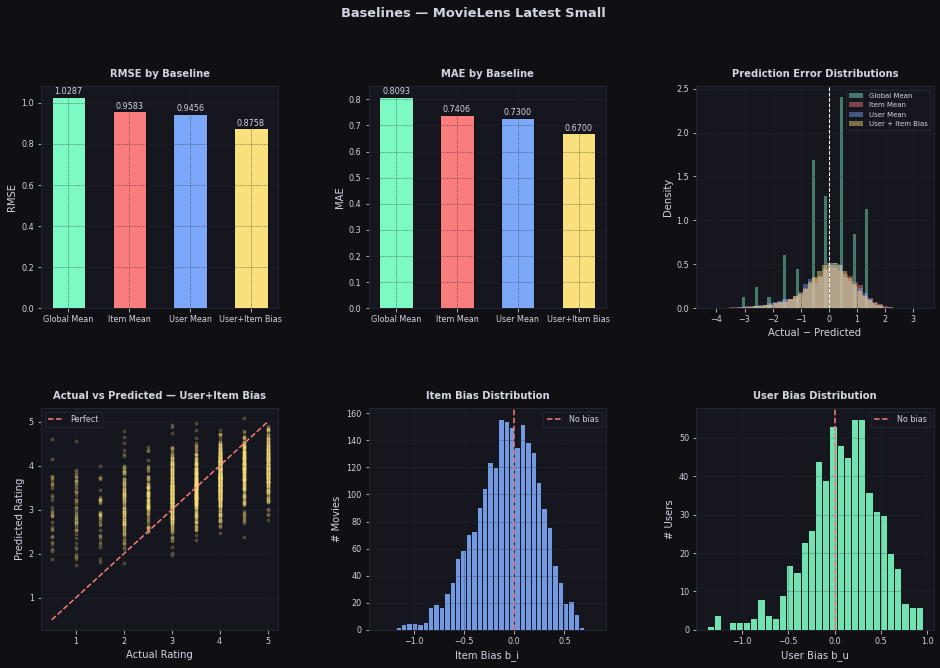

In [29]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

colors = [ACCENT, ACCENT2, ACCENT3, ACCENT4]
names  = [r["name"] for r in results]
rmses  = [r["rmse"] for r in results]
maes   = [r["mae"]  for r in results]

# (a) RMSE comparison
ax = fig.add_subplot(gs[0, 0])
bars = ax.bar(range(len(results)), rmses, color=colors, edgecolor=BG, width=0.55)
for b, v in zip(bars, rmses):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003,
            f"{v:.4f}", ha="center", va="bottom", color=TEXT_C, fontsize=8)
ax.set_xticks(range(len(results)))
ax.set_xticklabels(["Global Mean", "Item Mean", "User Mean", "User+Item Bias"], fontsize=8)
ax.set_ylabel("RMSE")
style_ax(ax, "RMSE by Baseline")

# (b) MAE comparison
ax = fig.add_subplot(gs[0, 1])
bars = ax.bar(range(len(results)), maes, color=colors, edgecolor=BG, width=0.55)
for b, v in zip(bars, maes):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003,
            f"{v:.4f}", ha="center", va="bottom", color=TEXT_C, fontsize=8)
ax.set_xticks(range(len(results)))
ax.set_xticklabels(["Global Mean", "Item Mean", "User Mean", "User+Item Bias"], fontsize=8)
ax.set_ylabel("MAE")
style_ax(ax, "MAE by Baseline")

# (c) Prediction error distributions
ax = fig.add_subplot(gs[0, 2])
actual = test["rating"].values
for r, c in zip(results, colors):
    errors = actual - r["predictions"]
    ax.hist(errors, bins=40, alpha=0.45, color=c, label=r["name"].split("(")[0].strip(), density=True)
ax.axvline(0, color="white", lw=1, linestyle="--")
ax.set_xlabel("Actual − Predicted")
ax.set_ylabel("Density")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=7)
style_ax(ax, "Prediction Error Distributions")

# (d) Actual vs predicted — User+Item Bias (best baseline)
ax = fig.add_subplot(gs[1, 0])
sample = np.random.default_rng(0).choice(len(preds_bias), min(2000, len(preds_bias)), replace=False)
ax.scatter(actual[sample], preds_bias[sample], alpha=0.2, s=8, color=ACCENT4)
ax.plot([0.5, 5], [0.5, 5], color=ACCENT2, lw=1.5, linestyle="--", label="Perfect")
ax.set_xlabel("Actual Rating"); ax.set_ylabel("Predicted Rating")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Actual vs Predicted — User+Item Bias")

# (e) Item bias distribution — what the model thinks of each movie
ax = fig.add_subplot(gs[1, 1])
ax.hist(item_bias.values, bins=40, color=ACCENT3, edgecolor=BG, alpha=0.9)
ax.axvline(0, color=ACCENT2, lw=1.5, linestyle="--", label="No bias")
ax.set_xlabel("Item Bias b_i"); ax.set_ylabel("# Movies")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Item Bias Distribution")

# (f) User bias distribution — how generous/harsh each user is
ax = fig.add_subplot(gs[1, 2])
ax.hist(user_bias.values, bins=30, color=ACCENT, edgecolor=BG, alpha=0.9)
ax.axvline(0, color=ACCENT2, lw=1.5, linestyle="--", label="No bias")
ax.set_xlabel("User Bias b_u"); ax.set_ylabel("# Users")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "User Bias Distribution")

fig.suptitle("Baselines — MovieLens Latest Small",
             color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


## 9. Sanity Checks & Observations

A few things worth verifying before moving to MF.


In [30]:
# Most positively / negatively biased movies (with enough ratings to trust)
item_stats_full = train.groupby("movie_idx")["rating"].agg(["mean","count"]).reset_index()
item_stats_full = item_stats_full[item_stats_full["count"] >= 20].copy()
item_stats_full["bias"] = item_bias.reindex(item_stats_full["movie_idx"]).values

movie_map = movies.set_index("movie_idx")[["title_clean","year"]]
item_stats_full = item_stats_full.join(movie_map, on="movie_idx")

print("Top 10 most positively biased movies (≥20 ratings):")
top_pos = item_stats_full.nlargest(10, "bias")[["title_clean","year","mean","count","bias"]]
print(top_pos.to_string(index=False))
print()

print("Top 10 most negatively biased movies (≥20 ratings):")
top_neg = item_stats_full.nsmallest(10, "bias")[["title_clean","year","mean","count","bias"]]
print(top_neg.to_string(index=False))
print()

# Most generous / harshest users
user_bias_df = user_bias.reset_index()
user_bias_df.columns = ["user_idx", "bias"]
print("5 most generous users (highest b_u):")
print(user_bias_df.nlargest(5, "bias").to_string(index=False))
print()
print("5 harshest users (lowest b_u):")
print(user_bias_df.nsmallest(5, "bias").to_string(index=False))


Top 10 most positively biased movies (≥20 ratings):
                                                         title_clean   year     mean  count     bias
                                           Shawshank Redemption, The 1994.0 4.419014    284 0.806796
                                                      Godfather, The 1972.0 4.300578    173 0.677601
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb 1964.0 4.308140     86 0.648879
                                                          Fight Club 1999.0 4.260204    196 0.643560
                                                  Lawrence of Arabia 1962.0 4.381579     38 0.631568
                                                       Departed, The 2006.0 4.275862     87 0.620707
                                                 Princess Bride, The 1987.0 4.244186    129 0.612868
                                  Star Wars: Episode IV - A New Hope 1977.0 4.221277    235 0.611448
                                       